# LeetCode #105: Construct Binary Tree from Preorder and Inorder Traversal

https://leetcode.com/problems/construct-binary-tree-from-preorder-and-inorder-traversal/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Recursive + Linear Search | O(n²) | O(n) | Linear scan to find root in inorder |
| **Recursion + HashMap ★** | **O(n)** | **O(n)** | Pre-map inorder positions for O(1) lookup |

---

## Understanding the Methods

### Brute Force (Linear Search)
At each recursive call, scan inorder array to find root position. Total O(n) calls × O(n) scan = O(n²).

### Recursion + HashMap (Optimal ★)
Pre-build a map from value → inorder index. Then `preorder[preStart]` is always the current root. Find it O(1) in the map to compute `leftSize = inRoot - inStart`. Recurse left and right with adjusted index bounds.

## Constraints
- 1 ≤ n ≤ 3000
- preorder and inorder have same elements, no duplicates

## Solutions

### C#

In [ ]:
public class Solution {
    private Dictionary<int,int> inorderMap;
    private int[] preorder;

    public TreeNode BuildTree(int[] preorder, int[] inorder) {
        this.preorder   = preorder;
        this.inorderMap = new Dictionary<int,int>();
        for (int i = 0; i < inorder.Length; i++)
            inorderMap[inorder[i]] = i;
        return Build(0, preorder.Length - 1, 0, inorder.Length - 1);
    }

    private TreeNode Build(int preStart, int preEnd, int inStart, int inEnd) {
        if (preStart > preEnd) return null;
        int rootVal  = preorder[preStart];
        int inRoot   = inorderMap[rootVal];
        int leftSize = inRoot - inStart;
        var node     = new TreeNode(rootVal);
        node.left  = Build(preStart + 1,            preStart + leftSize, inStart,    inRoot - 1);
        node.right = Build(preStart + leftSize + 1, preEnd,              inRoot + 1, inEnd);
        return node;
    }
}

### Python

In [ ]:
class Solution:
    def buildTree(self, preorder: list[int], inorder: list[int]):
        inorder_map = {v: i for i, v in enumerate(inorder)}

        def build(pre_start, pre_end, in_start, in_end):
            if pre_start > pre_end:
                return None
            root_val   = preorder[pre_start]
            in_root    = inorder_map[root_val]
            left_size  = in_root - in_start
            node       = TreeNode(root_val)
            node.left  = build(pre_start + 1,             pre_start + left_size, in_start,   in_root - 1)
            node.right = build(pre_start + left_size + 1, pre_end,               in_root + 1, in_end)
            return node

        return build(0, len(preorder) - 1, 0, len(inorder) - 1)

### Go

In [ ]:
func buildTree(preorder []int, inorder []int) *TreeNode {
    inMap := make(map[int]int, len(inorder))
    for i, v := range inorder { inMap[v] = i }

    var build func(ps, pe, is, ie int) *TreeNode
    build = func(ps, pe, is, ie int) *TreeNode {
        if ps > pe { return nil }
        rootVal  := preorder[ps]
        inRoot   := inMap[rootVal]
        leftSize := inRoot - is
        node     := &TreeNode{Val: rootVal}
        node.Left  = build(ps+1,            ps+leftSize, is,      inRoot-1)
        node.Right = build(ps+leftSize+1,   pe,          inRoot+1, ie)
        return node
    }
    return build(0, len(preorder)-1, 0, len(inorder)-1)
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;
use std::collections::HashMap;

impl Solution {
    pub fn build_tree(preorder: Vec<i32>, inorder: Vec<i32>) -> Option<Rc<RefCell<TreeNode>>> {
        let in_map: HashMap<i32,usize> = inorder.iter().enumerate().map(|(i,&v)|(v,i)).collect();

        fn build(
            preorder: &[i32], ps: usize, pe: usize,
            in_map:   &HashMap<i32,usize>, is: usize, ie: usize,
        ) -> Option<Rc<RefCell<TreeNode>>> {
            if ps > pe { return None; }
            let root_val  = preorder[ps];
            let in_root   = in_map[&root_val];
            let left_size = in_root - is;
            let node = Rc::new(RefCell::new(TreeNode::new(root_val)));
            node.borrow_mut().left  = build(preorder, ps+1,            ps+left_size, in_map, is,       in_root-1);
            node.borrow_mut().right = build(preorder, ps+left_size+1,  pe,           in_map, in_root+1, ie);
            Some(node)
        }
        let n = preorder.len();
        if n == 0 { return None; }
        build(&preorder, 0, n-1, &in_map, 0, n-1)
    }
}

## Example Scenarios

### 1. Common Case — Standard 5-Node Tree
**Input:** `preorder = [3, 9, 20, 15, 7], inorder = [9, 3, 15, 20, 7]`

Root = preorder[0] = 3. HashMap lookup: 3 at inorder[1]. leftSize = 1. Left subtree: pre[1..1]=[9], in[0..0]=[9]. Right subtree: pre[2..4]=[20,15,7], in[2..4]=[15,20,7]. Recurse each half.

*Why tricky:* Baseline. Confirms the index arithmetic: $leftSize = inRoot - inStart$, left preorder range = $[preStart+1,\; preStart+leftSize]$.

$leftSize = 1 - 0 = 1$

**Output:** `[3, 9, 20, null, null, 15, 7]`

### 2. Slightly Complex — All-Left-Children Chain
**Input:** `preorder = [1, 2, 3, 4], inorder = [4, 3, 2, 1]`

Root = 1, inRoot = 3, leftSize = 3. Every node is a left child. preorder and inorder are exact reverses. Every rightSize = 0 — the right recursive call always hits base case.

*Why tricky:* When preorder is the reverse of inorder, the tree is fully left-skewed. Tests the left-only path through recursion. $rightSize = 0$ at every level.

$preorder = \text{reverse}(inorder) \implies$ all-left-children

**Output:** `[1, 2, null, 3, null, 4]`

### 3. Edge Case: Time Factor — Right-Skewed 3000-Node Chain
**Input:** `preorder = [1, 2, ..., 3000], inorder = [1, 2, ..., 3000]` (identical arrays, max $n$)

When preorder = inorder, every node is a right child. Root = 1, inRoot = 0, leftSize = 0. Each call processes one node, 3000 calls total. HashMap gives $O(1)$ lookup per call.

*Why tricky:* Max $n = 3000$. Without HashMap: $O(n^2) = 9 \times 10^6$ ops. With HashMap: $O(n) = 3000$. Recursion stack = 3000 frames.

$O(n^2)$ brute force vs $O(n)$ HashMap

**Output:** `right-skewed chain [1, null, 2, null, ..., null, 3000]`

### 4. Edge Case: Space Factor — HashMap Fills Completely (3000 Entries)
**Input:** `preorder/inorder for a balanced BST of 3000 nodes`

HashMap stores all 3000 value→index entries regardless of tree shape. Balanced tree: recursion stack = $O(\log n) \approx 12$. Space is dominated by the HashMap at $O(n)$.

*Why tricky:* HashMap size = $O(n) = 3000$ always, independent of tree shape. The map, not the stack, dominates space. Total: $O(n)$ for map + $O(n)$ for output + $O(\log n)$ for stack.

$S_{map} = O(n)$, $S_{stack} = O(\log n)$ (balanced)

**Output:** `balanced tree with root at center, depth ~12`

### 5. Almost-Impossible but Plausible — Single Node at Extreme Value
**Input:** `preorder = [-3000], inorder = [-3000]`

preStart = preEnd = 0. Root = -3000. inRoot = 0, leftSize = 0. Both recursive calls hit $preStart > preEnd$, returning null. Single leaf created. Boundary value $-3000$.

*Why tricky:* Minimum input ($n = 1$) with extreme negative boundary. Tests that HashMap handles single entries and negative keys. Off-by-one in index bounds would crash here.

$n = 1$, $V = -3000$ (constraint boundary)

**Output:** `[-3000]`

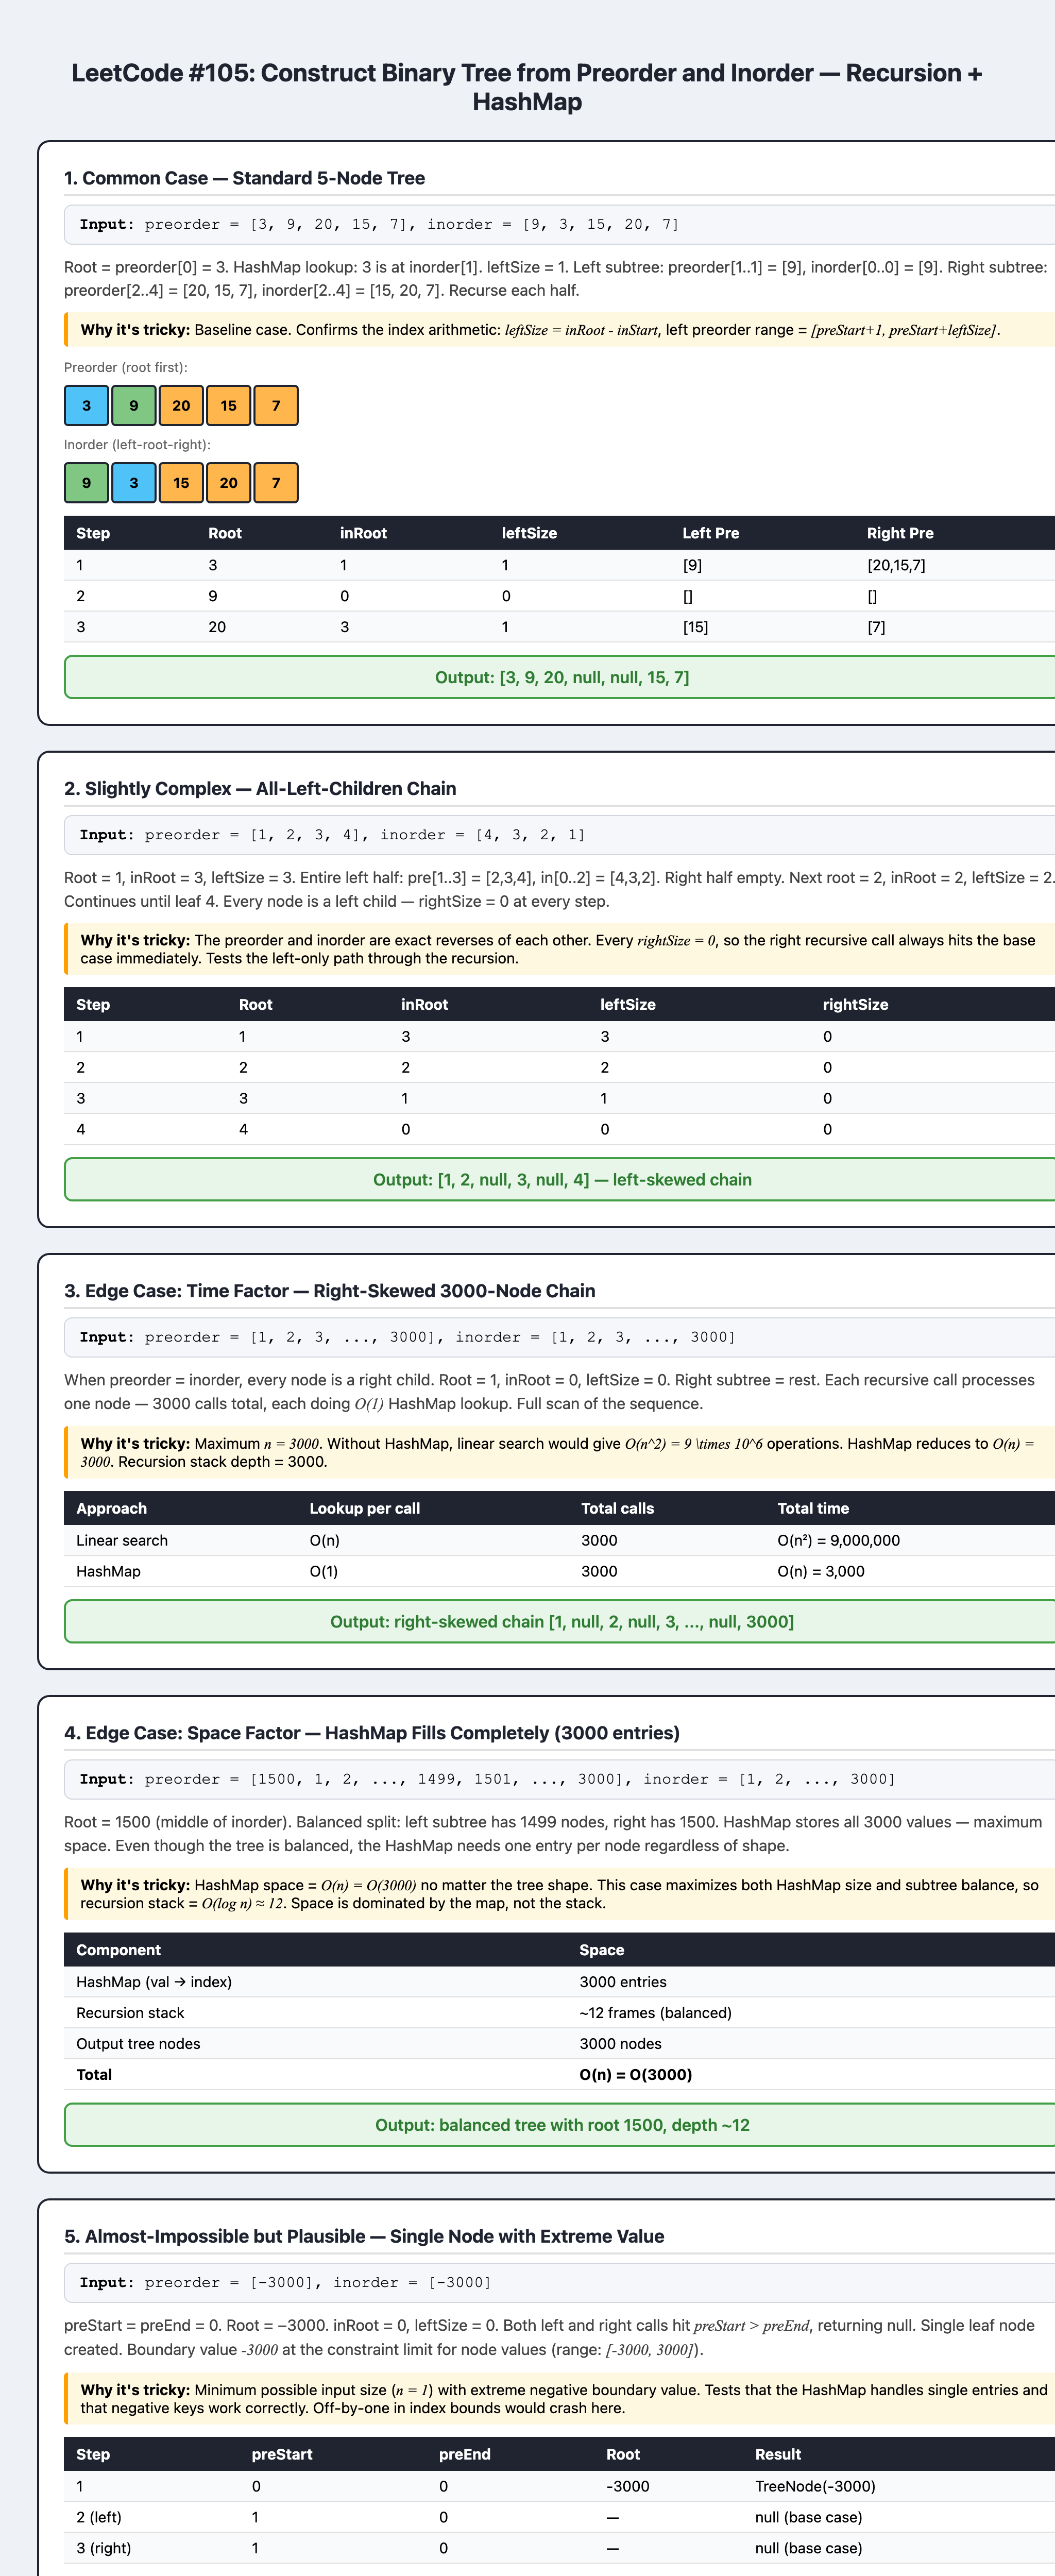